In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
#set random seeds for reproducibility
torch.manual_seed(42)

In [3]:
df = pd.read_csv(r'E:\Pyhton code\Data Sets\archive\fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


ValueError: not enough values to unpack (expected 4, got 3)

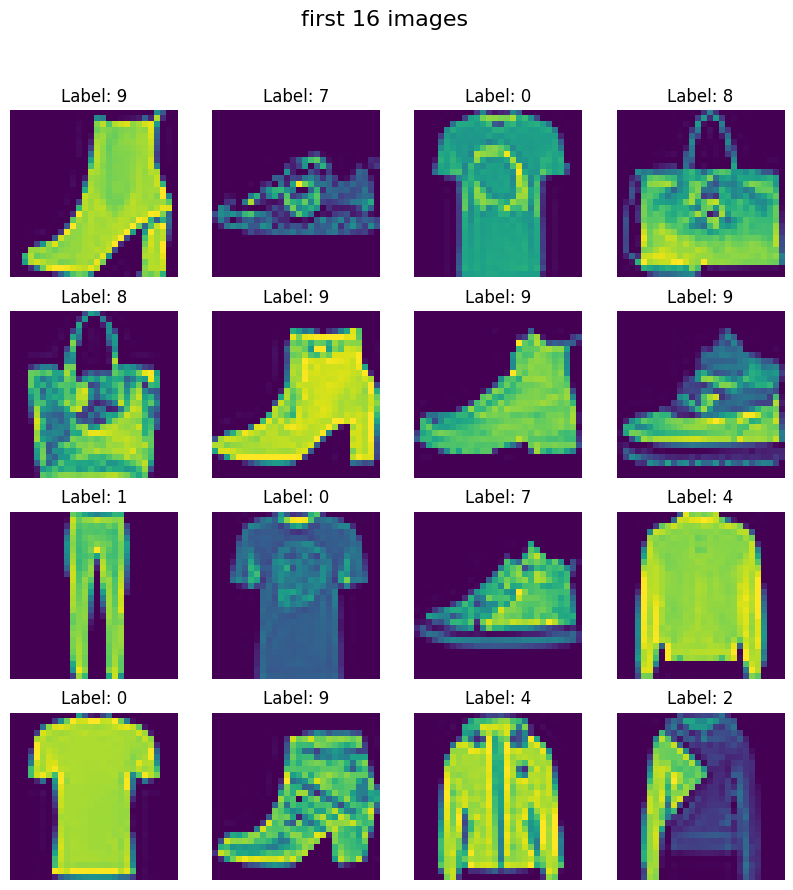

In [4]:
# create a 4 x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('first 16 images', fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img)
    ax.set_title(f'Label: {df.iloc[i, 0]}')
    ax.axis('off')
    
plt.tight_layout(rect = {0,0,1,0.96})
plt.show()

In [6]:
# data separation 
X =  df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [7]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# scaling features
x_train = x_train / 255.0
x_test = x_test / 255.0

In [17]:
#create customdataset class
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [18]:
#create train dataset object
train_dataset = CustomDataset(x_train, y_train)

In [19]:
#create test dataset object
test_dataset = CustomDataset(x_test, y_test)

In [20]:
# create train and test laoder
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
#define nn class
class NeuralNetwork(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        x = self.model(x)
        return x

In [22]:
ephocs = 100
learning_rate = 0.01


In [23]:
model = NeuralNetwork(x_train.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [24]:
for epoch in range(ephocs):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
         
        total_epoch_loss += loss.item()
    print(f'Epoch [{epoch+1}/{ephocs}], Loss: {total_epoch_loss/len(train_loader):.4f}')

Epoch [1/100], Loss: 2.2540
Epoch [2/100], Loss: 2.0201
Epoch [3/100], Loss: 1.5608
Epoch [4/100], Loss: 1.2199
Epoch [5/100], Loss: 1.0405
Epoch [6/100], Loss: 0.9359
Epoch [7/100], Loss: 0.8657
Epoch [8/100], Loss: 0.8144
Epoch [9/100], Loss: 0.7746
Epoch [10/100], Loss: 0.7449
Epoch [11/100], Loss: 0.7199
Epoch [12/100], Loss: 0.6941
Epoch [13/100], Loss: 0.6757
Epoch [14/100], Loss: 0.6567
Epoch [15/100], Loss: 0.6353
Epoch [16/100], Loss: 0.6231
Epoch [17/100], Loss: 0.6081
Epoch [18/100], Loss: 0.5929
Epoch [19/100], Loss: 0.5839
Epoch [20/100], Loss: 0.5678
Epoch [21/100], Loss: 0.5617
Epoch [22/100], Loss: 0.5463
Epoch [23/100], Loss: 0.5390
Epoch [24/100], Loss: 0.5256
Epoch [25/100], Loss: 0.5205
Epoch [26/100], Loss: 0.5090
Epoch [27/100], Loss: 0.5054
Epoch [28/100], Loss: 0.4958
Epoch [29/100], Loss: 0.4893
Epoch [30/100], Loss: 0.4833
Epoch [31/100], Loss: 0.4763
Epoch [32/100], Loss: 0.4709
Epoch [33/100], Loss: 0.4642
Epoch [34/100], Loss: 0.4612
Epoch [35/100], Loss: 0

In [25]:
model.eval()

NeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [26]:
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()
        
print(f'Accuracy of the model on the test images: {100 * correct / total:.2f}%')

Accuracy of the model on the test images: 84.17%


# Using CNN

In [9]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [10]:
train_dataset = CustomDataset(x_train, y_train)
test_dataset = CustomDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [11]:
#define nn class
class NeuralNetwork(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2)
            
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        
        return x

In [12]:

ephocs = 100
learning_rate = 0.01


In [ ]:
model = NeuralNetwork(1)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [14]:
for epoch in range(ephocs):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
         
        total_epoch_loss += loss.item()
    print(f'Epoch [{epoch+1}/{ephocs}], Loss: {total_epoch_loss/len(train_loader):.4f}')

Epoch [1/100], Loss: 1.3862
Epoch [2/100], Loss: 0.8260
Epoch [3/100], Loss: 0.6885
Epoch [4/100], Loss: 0.5748
Epoch [5/100], Loss: 0.5294
Epoch [6/100], Loss: 0.4699
Epoch [7/100], Loss: 0.4358
Epoch [8/100], Loss: 0.3854
Epoch [9/100], Loss: 0.3417
Epoch [10/100], Loss: 0.3241
Epoch [11/100], Loss: 0.2787
Epoch [12/100], Loss: 0.2681
Epoch [13/100], Loss: 0.2419
Epoch [14/100], Loss: 0.2285
Epoch [15/100], Loss: 0.2047
Epoch [16/100], Loss: 0.1864
Epoch [17/100], Loss: 0.1609
Epoch [18/100], Loss: 0.1681
Epoch [19/100], Loss: 0.1429
Epoch [20/100], Loss: 0.1314
Epoch [21/100], Loss: 0.1101
Epoch [22/100], Loss: 0.1032
Epoch [23/100], Loss: 0.0965
Epoch [24/100], Loss: 0.0931
Epoch [25/100], Loss: 0.0781
Epoch [26/100], Loss: 0.0674
Epoch [27/100], Loss: 0.0692
Epoch [28/100], Loss: 0.0643
Epoch [29/100], Loss: 0.0621
Epoch [30/100], Loss: 0.0606
Epoch [31/100], Loss: 0.0577
Epoch [32/100], Loss: 0.0458
Epoch [33/100], Loss: 0.0382
Epoch [34/100], Loss: 0.0433
Epoch [35/100], Loss: 0

In [15]:
model.eval()

NeuralNetwork(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [16]:
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()
        
print(f'Accuracy of the model on the test images: {100 * correct / total:.2f}%')

Accuracy of the model on the test images: 87.42%
